<a href="https://colab.research.google.com/github/OuhmadMohamed/DI_Bootcamp/blob/main/Week4/Day5/Daily_Challenge_W4_D5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Daily Challenge:** Interactive Data Visualization with Matplotlib and Seaborn

1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.widgets import Cursor

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

2. Load and Preprocess Data

In [12]:
#Since your dataset uses commas as decimal separators:

df = pd.read_excel("US_Superstore_data.xls")#, engine='xlrd')


In [13]:
#Convert Dates
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True
)

df['Ship Date'] = pd.to_datetime(
    df['Ship Date'],
    dayfirst=True
)

In [14]:
#Convert Numeric Columns
df['Sales'] = (
    df['Sales']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['Profit'] = (
    df['Profit']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)

df['Discount'] = (
    df['Discount']
    .astype(str)
    .str.replace(',', '.', regex=False)
    .astype(float)
)


In [15]:
#Check Missing Values
print(df.isnull().sum())


Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [16]:
#Exploratory Analysis
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [18]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355648,2016-05-03 23:06:58.571142912,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


3. Matplotlib Visualization

A. Interactive Sales Trend Over Time

In [19]:
#Create yearly sales totals:

sales_year = (
    df.groupby(
        df['Order Date'].dt.year
    )['Sales']
    .sum()
)

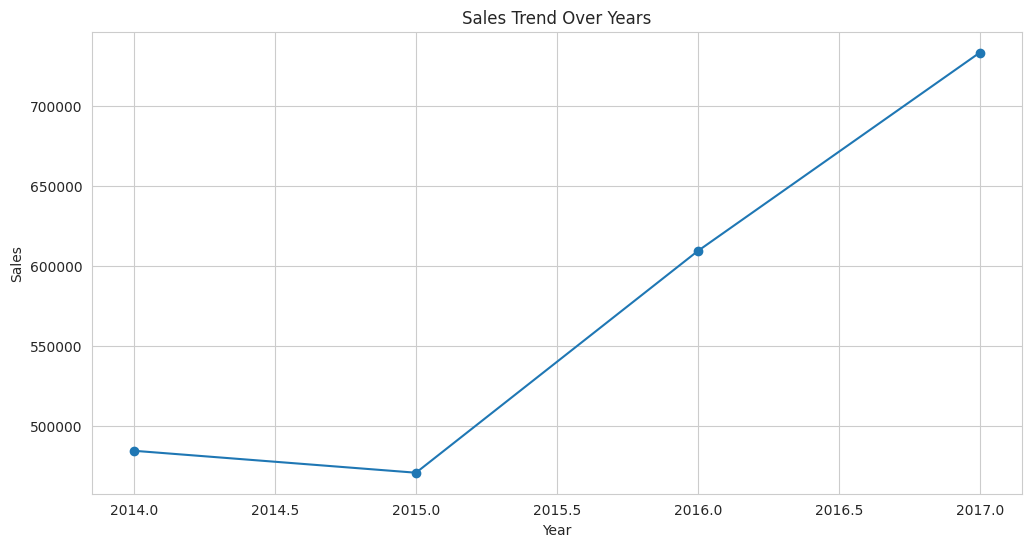

In [20]:
#Interactive Line Chart
fig, ax = plt.subplots(figsize=(12,6))

line, = ax.plot(
    sales_year.index,
    sales_year.values,
    marker='o'
)

ax.set_title("Sales Trend Over Years")
ax.set_xlabel("Year")
ax.set_ylabel("Sales")

cursor = Cursor(
    ax,
    useblit=True,
    color='red',
    linewidth=1
)

plt.show()

Interpretation
* Reveals growth or decline in sales over time.
* Useful for identifying strong and weak years.

B. Sales Distribution by State (Map Alternative)

In [21]:
#Since Matplotlib alone does not provide a built-in US map, create a geographic sales visualization by state.

state_sales = (
    df.groupby('State')['Sales']
      .sum()
      .sort_values(ascending=False)
)

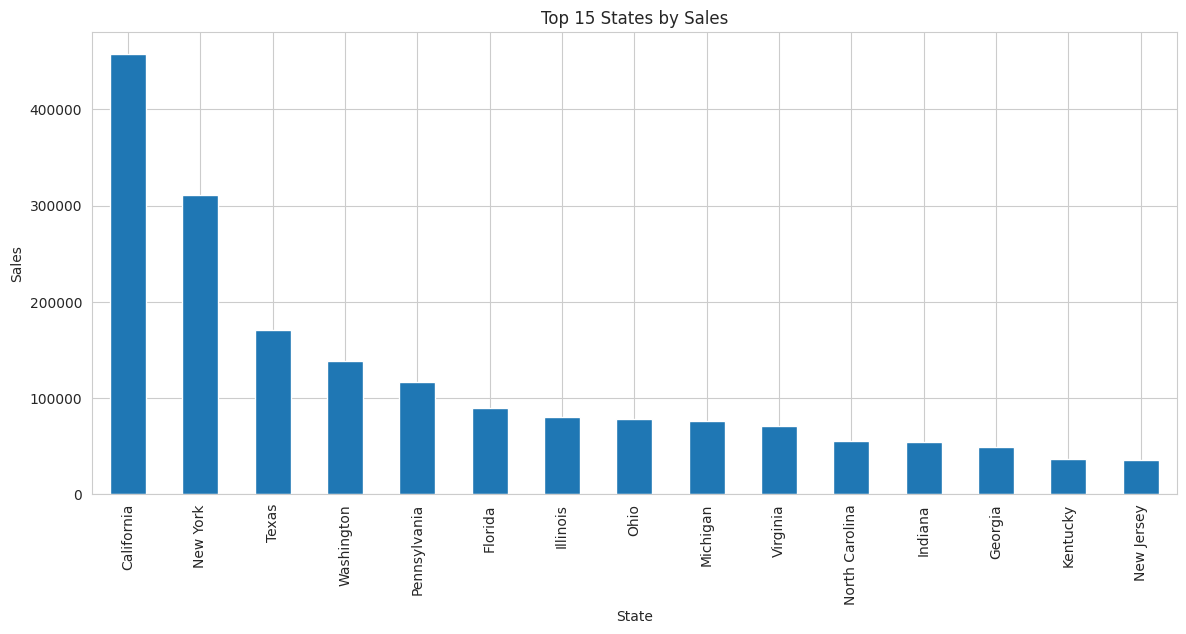

In [22]:
#Top States by Sales
plt.figure(figsize=(14,6))

state_sales.head(15).plot(
    kind='bar'
)

plt.title("Top 15 States by Sales")
plt.ylabel("Sales")

plt.show()

Interpretation
* Highlights strongest markets.
* Helps prioritize geographic marketing efforts.

4. Seaborn Visualizations

A. Top 10 Products by Sales

In [23]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

/tmp/ipykernel_4966/2924045653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


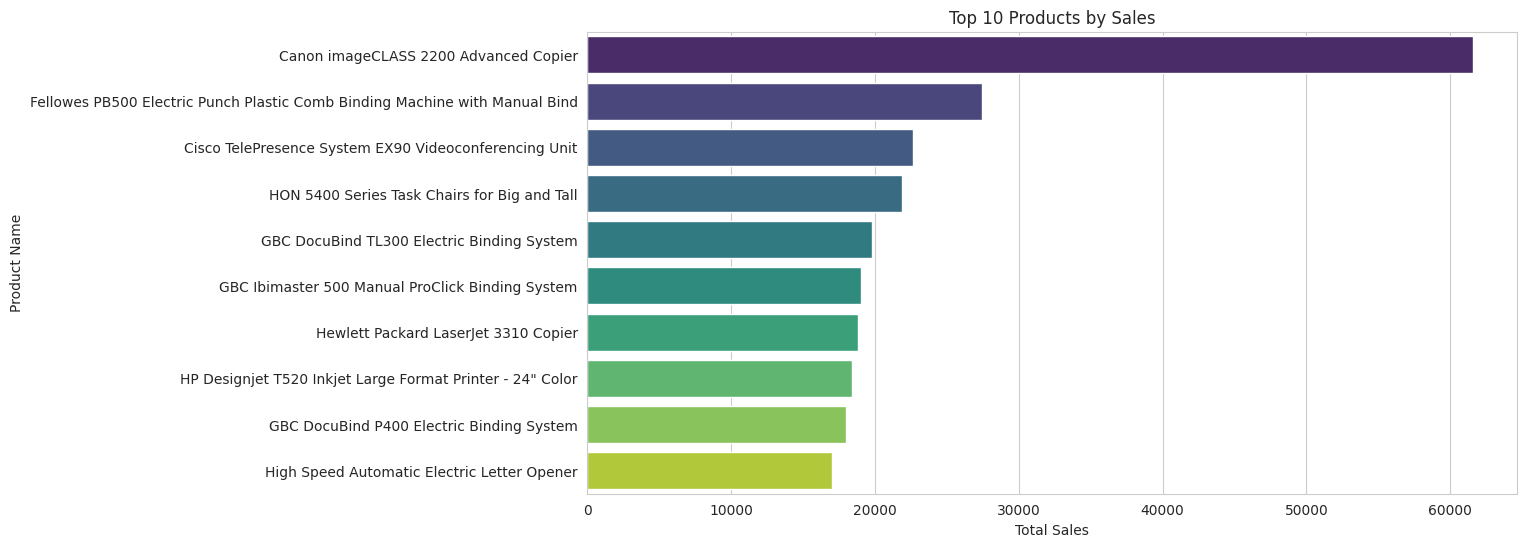

In [24]:
#Bar Chart
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette="viridis"
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")

plt.show()

Interpretation
* Identifies best-selling products.
* Useful for inventory and marketing campaigns.

B. Profit vs Discount

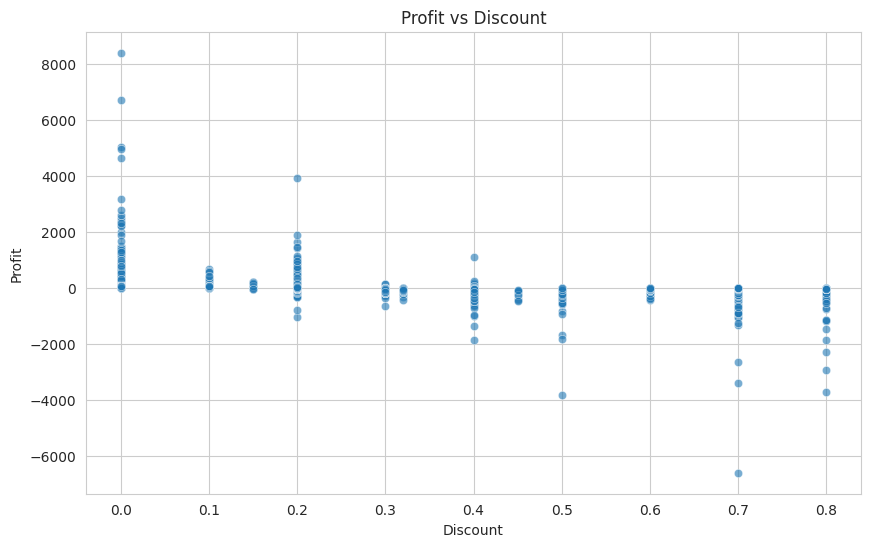

In [25]:
#Scatter Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    alpha=0.6
)

plt.title("Profit vs Discount")

plt.show()

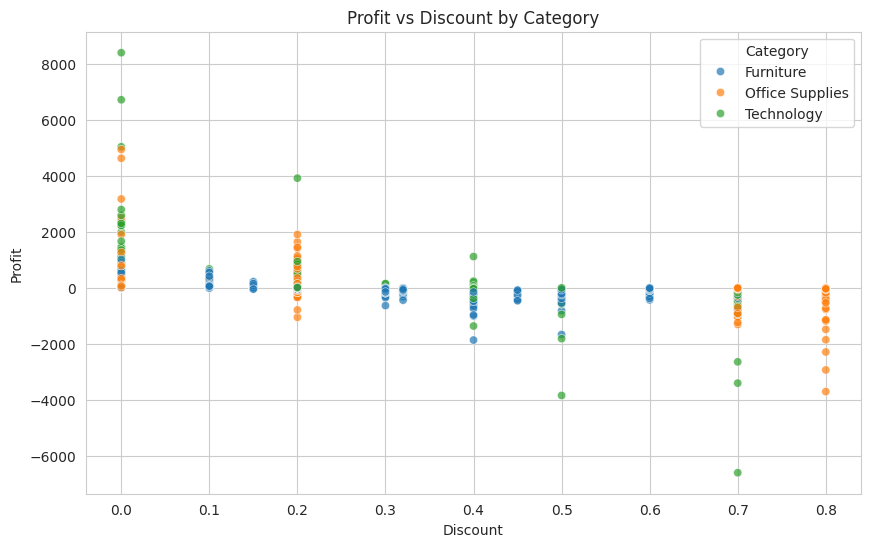

In [26]:
#Enhanced Version
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category',
    alpha=0.7
)

plt.title("Profit vs Discount by Category")

plt.show()

Interpretation

Typically shows:

* Higher discounts tend to reduce profits.
* Some heavily discounted products generate losses.
* Categories respond differently to discounts.



5. Additional Insight: Sales by Category

In [27]:
category_sales = (
    df.groupby('Category')['Sales']
      .sum()
      .sort_values(ascending=False)
)

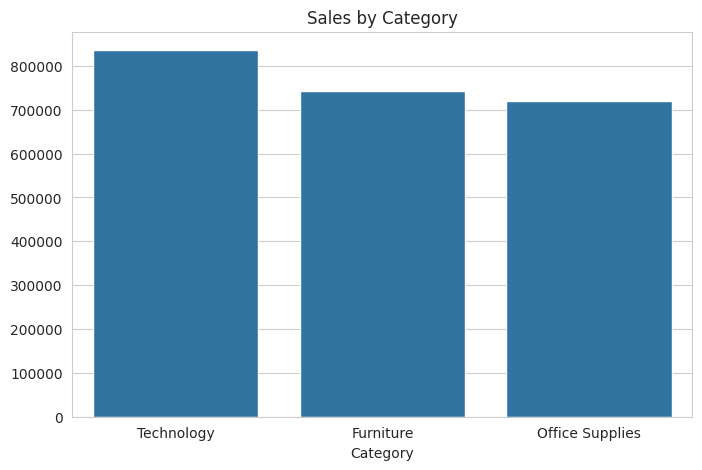

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Sales by Category")

plt.show()

6. Additional Insight: Monthly Sales Trend


In [29]:
monthly_sales = (
    df.groupby(
        df['Order Date'].dt.to_period('M')
    )['Sales']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

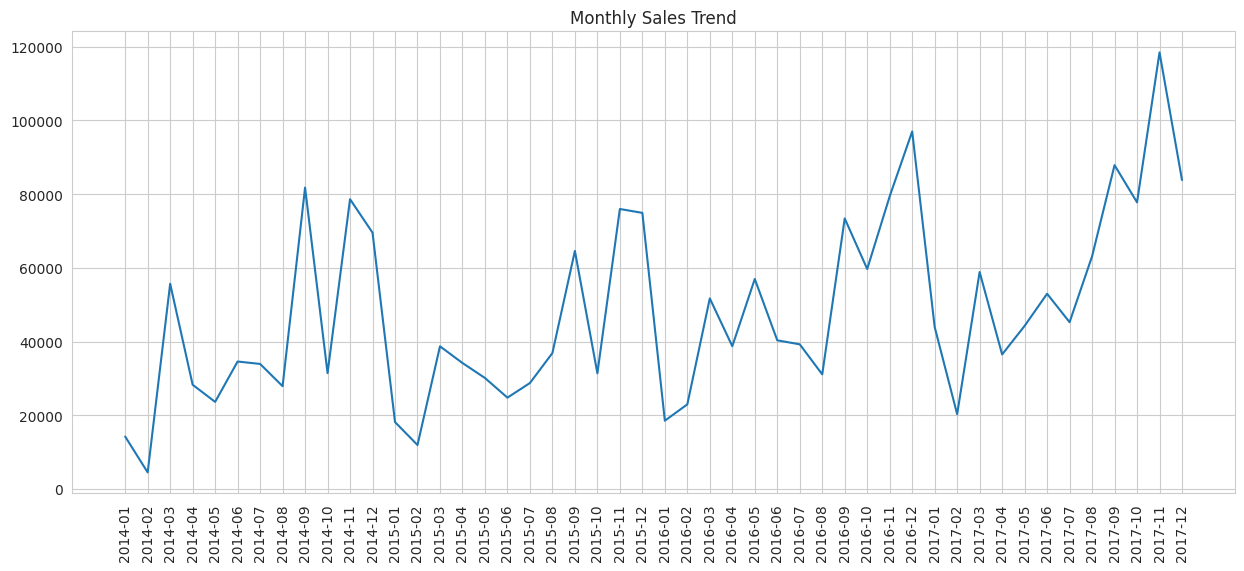

In [30]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values
)

plt.xticks(rotation=90)

plt.title("Monthly Sales Trend")

plt.show()